In [108]:
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve

In [110]:
df = pd.read_csv("Outputs/hotel_bookings_cleaned.csv")
print("Shape:", df.shape)

Shape: (84889, 36)


In [111]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,total_revenue,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01-07-2015,0,2,0.0,1-July-2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,01-07-2015,0,2,0.0,1-July-2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02-07-2015,1,1,75.0,1-July-2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,02-07-2015,1,1,75.0,1-July-2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,03-07-2015,2,2,196.0,1-July-2015


In [112]:
df.info

<bound method DataFrame.info of               hotel  is_canceled  lead_time  arrival_date_year  \
0      Resort Hotel            0        342               2015   
1      Resort Hotel            0        737               2015   
2      Resort Hotel            0          7               2015   
3      Resort Hotel            0         13               2015   
4      Resort Hotel            0         14               2015   
...             ...          ...        ...                ...   
84884    City Hotel            0         23               2017   
84885    City Hotel            0        102               2017   
84886    City Hotel            0         34               2017   
84887    City Hotel            0        109               2017   
84888    City Hotel            0        205               2017   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
0                   July                        27                          1   
1            

In [113]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,total_revenue
count,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.00000,84889.000000,84889.000000,84889.000000,...,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000
mean,0.271637,80.150444,2016.199637,26.721907,15.798337,1.001319,2.61313,1.866755,0.117683,0.010472,...,0.268822,78.846258,11.307001,0.768250,101.788429,0.082013,0.693541,3.614449,1.994911,373.848770
std,0.444806,86.460475,0.685912,13.812371,8.842121,1.032651,2.05764,0.627788,0.416169,0.112255,...,0.724677,109.037505,54.687341,10.145598,45.205950,0.278223,0.827720,2.767990,0.768068,334.516873
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,-63.800000
25%,0.000000,11.000000,2016.000000,15.000000,8.000000,0.000000,1.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,71.100000,0.000000,0.000000,2.000000,2.000000,150.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,96.530000,0.000000,0.000000,3.000000,2.000000,291.600000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,3.00000,2.000000,0.000000,0.000000,...,0.000000,195.000000,0.000000,0.000000,130.000000,0.000000,1.000000,5.000000,2.000000,484.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.00000,55.000000,10.000000,10.000000,...,21.000000,535.000000,543.000000,391.000000,227.000000,8.000000,5.000000,69.000000,55.000000,7590.000000


In [114]:
df = df.drop(columns=[
    'reservation_status',
    'reservation_status_date',
    'arrival_date'
])
print("After drop:", df.shape)

After drop: (84889, 33)


In [115]:
le = LabelEncoder()
cat_cols = ['hotel', 'meal', 'country',
            'market_segment', 'distribution_channel',
            'reserved_room_type', 'assigned_room_type',
            'deposit_type', 'customer_type',
            'arrival_date_month']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done !")
print(df.dtypes)

Encoding done !
hotel                               int64
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                  int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                int64
country                             int64
market_segment                      int64
distribution_channel                int64
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                  int64
assigned_room_type                  int64
booking_changes                     int64
deposit_type                        int64
agent             

In [116]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Cancellation rate:", y.mean())

X shape: (84889, 32)
y shape: (84889,)
Cancellation rate: 0.27163707900905887


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train size:", y_train.shape)
print("Test size:", y_test.shape)

Train size: (67911, 32)
Test size: (16978, 32)
Train size: (67911,)
Test size: (16978,)


In [118]:
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)

C:\Users\Tanmay Paul\PycharmProjects\Jupyter_Infotect_Project2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [119]:
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:,1]

In [120]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.7810
Precision: 0.6858
Recall: 0.3573


In [121]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[11611   755]
 [ 2964  1648]]


In [122]:
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86     12366
           1       0.69      0.36      0.47      4612

    accuracy                           0.78     16978
   macro avg       0.74      0.65      0.67     16978
weighted avg       0.77      0.78      0.76     16978



In [123]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [124]:
dt_pred = dt_model.predict(X_test)

In [125]:
print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall: {recall_score(y_test, dt_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, dt_pred):.4f}")

Decision Tree Results:
Accuracy: 0.8017
Precision: 0.6322
Recall: 0.6453
ROC-AUC: 0.7526


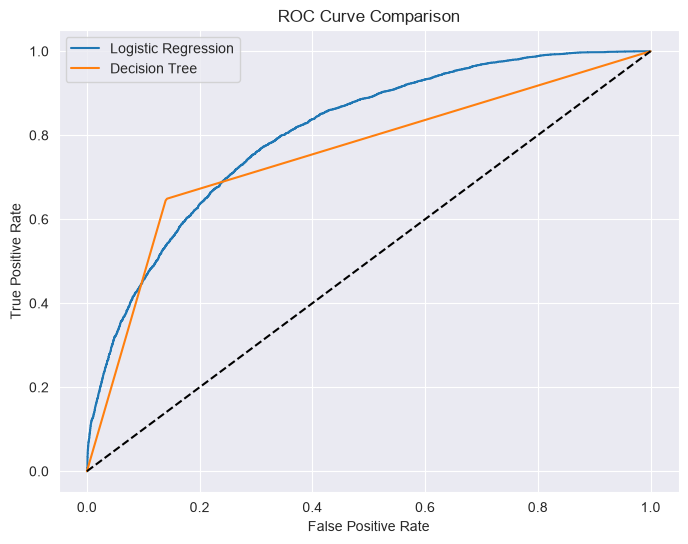

In [126]:
log_proba = log_model.predict_proba(X_test)[:,1]
dt_proba = dt_model.predict_proba(X_test)[:,1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_proba)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

plt.figure(figsize =(8,6))
plt.plot(log_fpr, log_tpr, label='Logistic Regression')
plt.plot(dt_fpr, dt_tpr, label='Decision Tree')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [127]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred),
                 accuracy_score(y_test, dt_pred)],
    'Precision': [precision_score(y_test, y_pred),
                  precision_score(y_test, dt_pred)],
    'Recall': [recall_score(y_test, y_pred),
               recall_score(y_test, dt_pred)],
    'ROC-AUC': [roc_auc_score(y_test, y_pred),
                roc_auc_score(y_test, dt_pred)]
})
print(results)

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression  0.780952   0.685809  0.357329  0.648137
1        Decision Tree  0.801685   0.632250  0.645273  0.752646


### Week 3 Summary:
- Two models were built: Logistic Regression
  and Decision Tree
- Decision Tree performed better in terms
  of Accuracy and Recall
- Recall is most important metric as we don't
  want to miss actual cancellations
- Both models confirmed lead time and deposit
  type as top cancellation predictors

In [128]:
import joblib
joblib.dump(dt_model, 'models/cancellation_model.pkl')
print("Model saved!")

Model saved!
